In [ ]:
from pycirclize import Circos
from pygenomeviz.parser import Fasta
from pygenomeviz.utils import load_example_fasta_dataset, ColorCycler, interpolate_color
from pygenomeviz.align import AlignCoord, Blast
from matplotlib.patches import Patch
import matplotlib.pyplot as plt

In [6]:
QUERY_TRACK_SIZE = 5
MIN_IDENTITY = 70
TICKS_INTERVAL = 100000

In [7]:
ref_fasta = "/home/jupyter/mary/ecoli_strains/Escherichia coli O157:H7 str. Sakai.fna"
strain_files = strain_files = [
    "/home/jupyter/mary/ecoli_strains/B_S169.fa",
    "/home/jupyter/mary/ecoli_strains/C_S170.fa",
    "/home/jupyter/mary/ecoli_strains/D_S183.fa",
    "/home/jupyter/mary/ecoli_strains/E_S171.fa",
    "/home/jupyter/mary/ecoli_strains/J_S176.fa",
    "/home/jupyter/mary/ecoli_strains/Q_S182.fa",
    "/home/jupyter/mary/ECOLI/ecoli_strains/GCF_022964775.1.fna"
]

target_fasta = Fasta(ref_fasta)
comp_fasta_list = [Fasta(f) for f in strain_files]

In [8]:
# Initialize circos instance
circos = Circos(
    sectors=target_fasta.get_seqid2size(),
    space=0 if len(target_fasta.get_seqid2size()) == 1 else 2,
)
circos.text(f"{target_fasta.name}\n({target_fasta.full_genome_length:,} bp)", size=13)

In [10]:
# Blast genome comparison & plot match blocks
min_r_pos = 100
comp_name2color = {}
for idx, comp_fasta in enumerate(comp_fasta_list):
    align_coords = Blast([target_fasta, comp_fasta]).run()
    align_coords = AlignCoord.filter(align_coords, identity_thr=MIN_IDENTITY)
    color = ColorCycler()
    comp_name2color[comp_fasta.name] = color
    min_r_pos -= QUERY_TRACK_SIZE
    for sector in circos.sectors:
        sector.add_track((min_r_pos, min_r_pos + QUERY_TRACK_SIZE), r_pad_ratio=0.1)
    for ac in align_coords:
        track = circos.get_sector(ac.query_name).tracks[-1] # Last added track in sector
        rect_color = interpolate_color(color, v=ac.identity, vmin=MIN_IDENTITY) # type: ignore
        track.rect(ac.query_start, ac.query_end, color=rect_color)

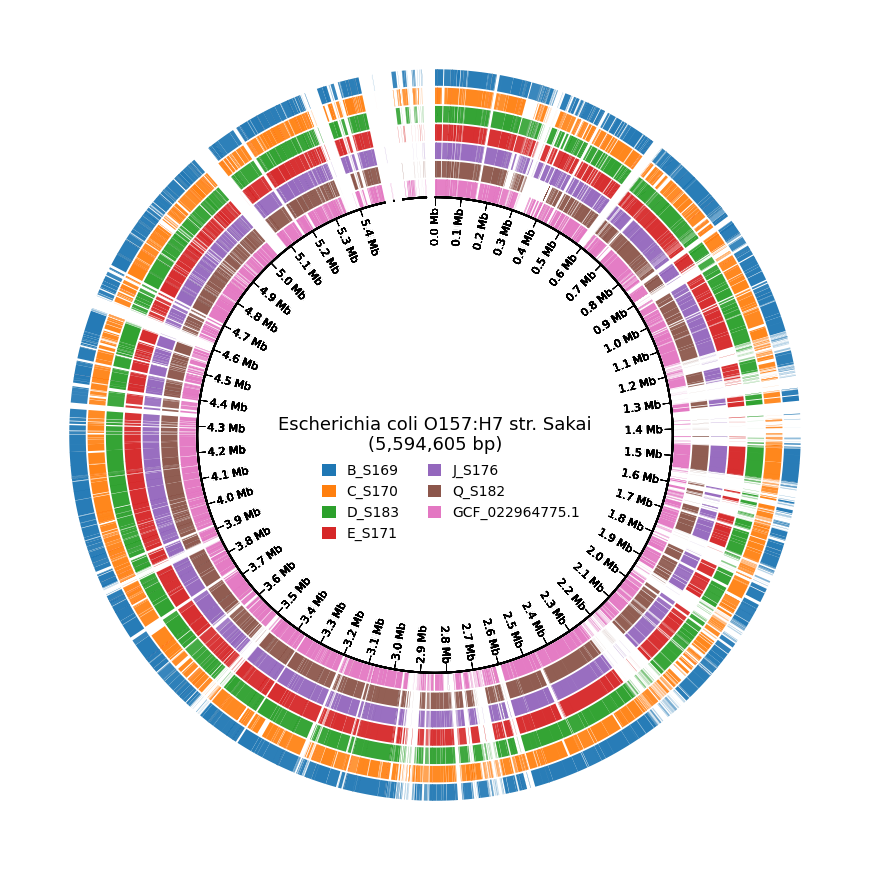

In [20]:
# Plot genomic sector axis & xticks
for sector in circos.sectors:
    track = sector.add_track((min_r_pos - 0.3, min_r_pos))
    track.axis(fc="black")
    if sector.size >= TICKS_INTERVAL:
        track.xticks_by_interval(
            TICKS_INTERVAL,
            outer=False,
            label_formatter=lambda v: f"{v/1000000:.1f} Mb",
            label_orientation="vertical",
        )

fig = circos.plotfig()

# Plot legend
_ = fig.legend(
    handles=[Patch(label=query_name, fc=color) for query_name, color in comp_name2color.items()],
    loc="upper center",
    bbox_to_anchor=(0.52, 0.48), 
    ncol = 2
)
plt.savefig('/home/jupyter/mary/ECOLI/work/ecoli_rings_wcw.svg', format='svg', dpi=600, bbox_inches='tight')